# Robust Sleep Staging under Distribution Shift

**Course**: AI for Medical Time Series  
**Dataset**: Sleep-EDF Expanded (PhysioNet) — https://physionet.org/content/sleep-edfx/1.0.0/  

**Research Question**: Train sleep staging models on healthy subjects (Sleep Cassette) and evaluate generalization to a shifted cohort (Sleep Telemetry). Quantify performance degradation under subject-level splits.

This notebook is an orchestrator for the workflow:

**Pipeline**:
1. **Preprocess** (filter, epoch)
2. **Feature extraction** with PSD and checkpointing
3. **Train** a classifier on SC (Sleep Cassette) and save the model checkpoint
4. **Evaluate** 
    - Evaluate in-distribution: SC → SC
    - Evaluate under distribution shift: SC → ST
    - Compare and analyze results


---

## 1. Imports & configuration

This notebook only orchestrates the pipeline. Each step delegates to a dedicated module in `rss/`.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from rss import evaluate, features, preprocess, train, utils

print('✓ Core libraries imported')

✓ Core libraries imported


## 2. Dataset paths

The paths below point to the downloaded Sleep-EDF files and the checkpoint folders used for intermediate artifacts.

In [2]:
CUSTOM_DIR = Path.cwd() # Update with actual path to project directory
# Data directory structure:
# data/
#       sleep-cassette/
#       sleep-telemetry/
DATA_DIR = CUSTOM_DIR / 'data' # Update with actual path to data
SC_DIR = DATA_DIR / 'sleep-cassette'
ST_DIR = DATA_DIR / 'sleep-telemetry'

# Checkpoint directories (modify as needed)
FEATURE_DIR_SC = CUSTOM_DIR / 'checkpoints/features/RF/sc'
FEATURE_DIR_ST = CUSTOM_DIR / 'checkpoints/features/RF/st'
MODEL_DIR = CUSTOM_DIR / 'checkpoints/model/RF'

for path in [FEATURE_DIR_SC, FEATURE_DIR_ST, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print('SC:', SC_DIR)
print('ST:', ST_DIR)
print('Feature checkpoints:', FEATURE_DIR_SC, FEATURE_DIR_ST)
print('Model checkpoint:', MODEL_DIR)

SC: c:\Users\E1024679\Documents\RobustSleepStaging\data\sleep-cassette
ST: c:\Users\E1024679\Documents\RobustSleepStaging\data\sleep-telemetry
Feature checkpoints: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\sc c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\st
Model checkpoint: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\model\RF


## 3. Data exploration & visualization

Before preprocessing, it helps to inspect one recording and the stage distribution. This keeps the dataset assumptions visible and makes distribution shift easier to explain.

In [3]:
def discover_pairs(root_dir):
    """Return sorted (psg, hypnogram) pairs from a Sleep-EDF cohort directory."""
    psgs = sorted(Path(root_dir).glob('*-PSG.edf'))
    pairs = []
    for psg in psgs:
        subject_id = psg.name[:6]
        hyp_files = list(Path(root_dir).glob(f'{subject_id}*-Hypnogram.edf'))
        if hyp_files:
            pairs.append((psg, hyp_files[0]))
    return pairs


sc_pairs = discover_pairs(SC_DIR)
st_pairs = discover_pairs(ST_DIR)
print(f'SC pairs found: {len(sc_pairs)}')
print(f'ST pairs found: {len(st_pairs)}')

example_psg, example_hyp = sc_pairs[0]
raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
annotations = mne.read_annotations(example_hyp)
raw.set_annotations(annotations)

print(f'Example recording: {example_psg.name}')
print(f'Channels in file: {raw.ch_names}')
print(f'Sampling frequency: {raw.info["sfreq"]} Hz')
print(f'Duration: {raw.times[-1] / 3600:.2f} h')
print(f'Annotations: {len(annotations)} segments')

SC pairs found: 153
ST pairs found: 44


C:\Users\E1024679\AppData\Local\Temp\ipykernel_28904\3121516847.py:19: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
C:\Users\E1024679\AppData\Local\Temp\ipykernel_28904\3121516847.py:19: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
C:\Users\E1024679\AppData\Local\Temp\ipykernel_28904\3121516847.py:19: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)


Example recording: SC4001E0-PSG.edf
Channels in file: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Sampling frequency: 100.0 Hz
Duration: 22.08 h
Annotations: 154 segments


C:\Users\E1024679\AppData\Local\Temp\ipykernel_28904\3121516847.py:21: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


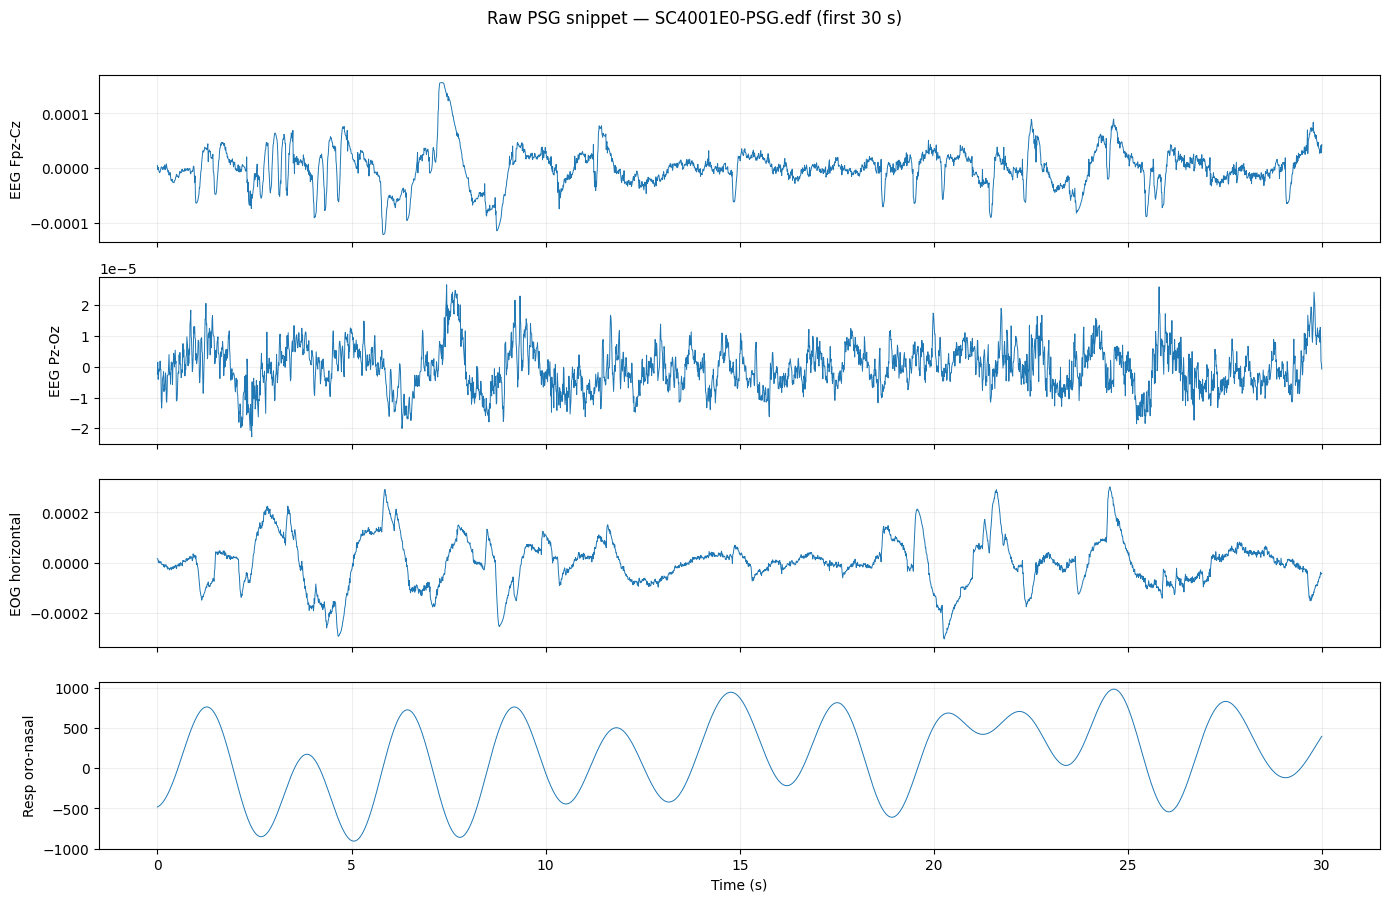

In [4]:
# Plot a short raw-signal snippet from the first few available channels
channels_to_plot = raw.ch_names[: min(4, len(raw.ch_names))]
start_sec = 0
end_sec = 30
start_sample = int(start_sec * raw.info['sfreq'])
end_sample = int(end_sec * raw.info['sfreq'])
times = np.arange(start_sample, end_sample) / raw.info['sfreq']
data, _ = raw[: len(channels_to_plot), start_sample:end_sample]

fig, axes = plt.subplots(len(channels_to_plot), 1, figsize=(14, 2.2 * len(channels_to_plot)), sharex=True)
if len(channels_to_plot) == 1:
    axes = [axes]

for ax, channel, signal in zip(axes, channels_to_plot, data):
    ax.plot(times, signal, lw=0.7)
    ax.set_ylabel(channel)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Raw PSG snippet — {example_psg.name} (first 30 s)', y=1.02)
plt.tight_layout()
plt.show()

Total annotated epochs: 154

Sleep stage distribution:
  Wake: 12 epochs (0.1h)
  N1: 24 epochs (0.2h)
  N2: 40 epochs (0.3h)
  N3: 71 epochs (0.6h)
  REM: 6 epochs (0.1h)


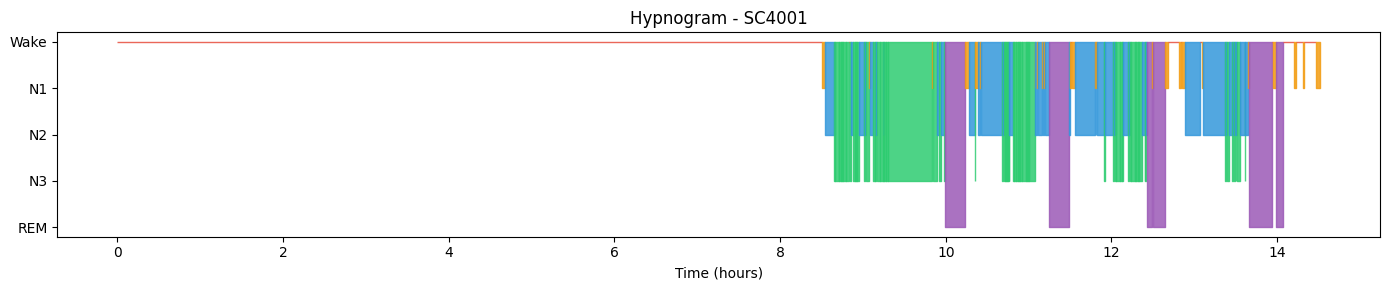

In [5]:
# Load and visualize hypnogram
annotations = mne.read_annotations(example_hyp)
stages = [preprocess.STAGE_MAP.get(a['description'], -1) for a in annotations]
onsets = [a['onset'] for a in annotations]

# Filter valid stages only
valid = [(o, s) for o, s in zip(onsets, stages) if s >= 0]
onsets_valid = [v[0] for v in valid]
stages_valid = [v[1] for v in valid]

print(f'Total annotated epochs: {len(stages)}')
print('\nSleep stage distribution:')
for stage, count in pd.Series(stages_valid).value_counts().sort_index().items():
    print(f'  {preprocess.STAGE_NAMES.get(stage, stage)}: {count} epochs ({count*30/3600:.1f}h)')
    
# Plot hypnogram
COLORS = {
    0: '#e74c3c',  # Wake - red
    1: '#f39c12',  # N1 - orange
    2: '#3498db',  # N2 - blue
    3: '#2ecc71',  # N3 - green
    4: '#9b59b6',  # REM - purple
}

hours = np.array(onsets_valid) / 3600
y = np.array(stages_valid)

fig, ax = plt.subplots(figsize=(14, 3))
for i in range(len(stages_valid) - 1):
    ax.fill_between([hours[i], hours[i+1]], [y[i], y[i]], [0, 0],
                    color=COLORS.get(y[i], 'gray'), alpha=0.85)

ax.set_yticks(list(preprocess.STAGE_NAMES.keys()))
ax.set_yticklabels(list(preprocess.STAGE_NAMES.values()))
ax.set_xlabel('Time (hours)')
ax.set_title(f'Hypnogram - {example_psg.name[:6]}')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Preprocess & feature extraction

This step loads each PSG/hypnogram pair, creates 30-second epochs, extracts PSD features, and stores one checkpoint per recording.

In [6]:
def process_recording_pairs(pairs, checkpoint_dir, cohort_name):
    """Preprocess a cohort and save one feature checkpoint per recording.

    Returns the number of recordings processed or found in the checkpoint folder.
    """
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    processed = 0

    for psg_path, hyp_path in pairs:
        checkpoint_file = checkpoint_dir / f'{psg_path.stem}.npz'
        if checkpoint_file.exists():
            processed += 1
            print(f'[{cohort_name}] checkpoint exists for {psg_path.name}, skipping')
            continue

        try:
            X_epochs, y_labels, sfreq = preprocess.load_subject_epochs(psg_path, hyp_path, preprocess.COMMON_CHANNELS, verbose=True)
            X_features, freqs = features.extract_psd_features(X_epochs, sfreq, verbose=True)
            subject_id = psg_path.name[:5]
            subject_ids = np.array([subject_id] * len(y_labels))
            features.save_recording_checkpoint( checkpoint_file, X_features=X_features, y_labels=y_labels,
                                               subject_ids=subject_ids, recording_id=psg_path.name)
            processed += 1
            print(f'[{cohort_name}] saved {psg_path.name} -> {X_features.shape}')
        except Exception as exc:
            print(f'[{cohort_name}] skipping {psg_path.name}: {exc}')

    return processed


### Run preprocessing

The function above only defines the preprocessing step. The next step is to actually run and builds the feature checkpoints.

In [7]:
processed_sc = process_recording_pairs(sc_pairs, FEATURE_DIR_SC, 'SC')
processed_st = process_recording_pairs(st_pairs, FEATURE_DIR_ST, 'ST')

[SC] checkpoint exists for SC4001E0-PSG.edf, skipping
[SC] checkpoint exists for SC4002E0-PSG.edf, skipping
[SC] checkpoint exists for SC4011E0-PSG.edf, skipping
[SC] checkpoint exists for SC4012E0-PSG.edf, skipping
[SC] checkpoint exists for SC4021E0-PSG.edf, skipping
[SC] checkpoint exists for SC4022E0-PSG.edf, skipping
[SC] checkpoint exists for SC4031E0-PSG.edf, skipping
[SC] checkpoint exists for SC4032E0-PSG.edf, skipping
[SC] checkpoint exists for SC4041E0-PSG.edf, skipping
[SC] checkpoint exists for SC4042E0-PSG.edf, skipping
[SC] checkpoint exists for SC4051E0-PSG.edf, skipping
[SC] checkpoint exists for SC4052E0-PSG.edf, skipping
[SC] checkpoint exists for SC4061E0-PSG.edf, skipping
[SC] checkpoint exists for SC4062E0-PSG.edf, skipping
[SC] checkpoint exists for SC4071E0-PSG.edf, skipping
[SC] checkpoint exists for SC4072E0-PSG.edf, skipping
[SC] checkpoint exists for SC4081E0-PSG.edf, skipping
[SC] checkpoint exists for SC4082E0-PSG.edf, skipping
[SC] checkpoint exists for S

## 5. Classification - Random Forest Baseline

After feature checkpoints are built, concatenate them, train a baseline model, save the model checkpoint, and report metrics for both validation and shifted evaluation.

In [8]:
# Build / load feature arrays from the checkpoint folders
model_path = MODEL_DIR / 'random_forest_sc.pkl'
scaler_path = MODEL_DIR / 'scaler_sc.pkl'

# Load SC features and labels for training and validation
X_sc, y_sc, sid_sc = utils.load_per_record_checkpoints(FEATURE_DIR_SC, load_mode='disk')
print('SC features:', X_sc.shape)

if X_sc.size > 0:
    unique_subjects = np.unique(sid_sc)
    print(unique_subjects)
    train_subjects, val_subjects = train_test_split(unique_subjects, test_size=0.2, random_state=42)
    print('Train subjects:', train_subjects)
    print('Validation subjects:', val_subjects)
    train_mask = np.isin(sid_sc, train_subjects)
    val_mask = np.isin(sid_sc, val_subjects)

    X_train_raw = X_sc[train_mask]
    y_train = y_sc[train_mask]
    X_val_raw = X_sc[val_mask]
    y_val = y_sc[val_mask]
    # Look for existing scaler checkpoint
    if scaler_path.exists():
        scaler = joblib.load(scaler_path)
        print('Loaded existing scaler checkpoint:', scaler_path)
        X_train = scaler.transform(X_train_raw)
    else:
        # Create new scaler, fit on training data, and save checkpoint
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        joblib.dump(scaler, scaler_path, compress=3)
        print('Saved scaler checkpoint:', scaler_path)

    X_val = scaler.transform(X_val_raw)
    print('✓ Feature scaling complete')
    
    # Look for existing model checkpoint
    if model_path.exists():
        clf = joblib.load(model_path)
        print('Loaded existing model checkpoint:', model_path)
    else:
        print('No model checkpoint found; training new model...')
        # train model and save checkpoint
        clf = train.random_forest(X_train, y_train, verbose=True)
        print('✓ Training complete')
        joblib.dump(clf, model_path, compress=3)
        print('Saved model checkpoint:', model_path)

else:
    print('No SC checkpoints found yet; run the preprocessing cell first.')

[utils] load_mode=disk — scanning checkpoint directory: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\sc
[utils] found 153 .npz files
[utils] scanned 50/153 files — total_epochs so far: 136394
[utils] scanned 100/153 files — total_epochs so far: 272478
[utils] scanned 150/153 files — total_epochs so far: 407016
SC features: (414961, 4744)
['SC400' 'SC401' 'SC402' 'SC403' 'SC404' 'SC405' 'SC406' 'SC407' 'SC408'
 'SC409' 'SC410' 'SC411' 'SC412' 'SC413' 'SC414' 'SC415' 'SC416' 'SC417'
 'SC418' 'SC419' 'SC420' 'SC421' 'SC422' 'SC423' 'SC424' 'SC425' 'SC426'
 'SC427' 'SC428' 'SC429' 'SC430' 'SC431' 'SC432' 'SC433' 'SC434' 'SC435'
 'SC436' 'SC437' 'SC438' 'SC440' 'SC441' 'SC442' 'SC443' 'SC444' 'SC445'
 'SC446' 'SC447' 'SC448' 'SC449' 'SC450' 'SC451' 'SC452' 'SC453' 'SC454'
 'SC455' 'SC456' 'SC457' 'SC458' 'SC459' 'SC460' 'SC461' 'SC462' 'SC463'
 'SC464' 'SC465' 'SC466' 'SC467' 'SC470' 'SC471' 'SC472' 'SC473' 'SC474'
 'SC475' 'SC476' 'SC477' 'SC480' 'SC481' 'SC482']


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  8.4min finished


[train] training complete — elapsed: 504.3s
✓ Training complete
Saved model checkpoint: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\model\RF\random_forest_sc.pkl


## 6. Evaluation
### In-Distribution Confusion Matrix (SC → SC)

Performance on the validation set from the same cohort used for training.

In [17]:
y_pred_val = clf.predict(X_val)
val_metrics = evaluate.get_predictions(y_val, y_pred_val)
print('=' * 40)
print('   IN-DISTRIBUTION METRICS (SC -> SC)')
print('=' * 40)
print(f'  Accuracy:      {val_metrics["accuracy"]:.3f}')
print(f'  Macro F1:      {val_metrics["macro_f1"]:.3f}')
print(f'  Cohen Kappa:   {val_metrics["kappa"]:.3f}')
print('=' * 40)


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s


   IN-DISTRIBUTION METRICS (SC -> SC)
  Accuracy:      0.900
  Macro F1:      0.723
  Cohen Kappa:   0.786


[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.6s finished


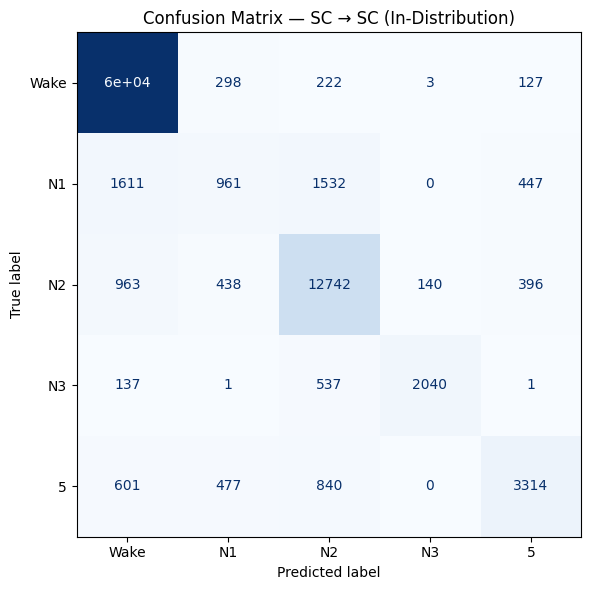

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix - SC -> SC
unique_sc = sorted(np.unique(np.concatenate([y_val, y_pred_val])))
labels_sc = [preprocess.STAGE_NAMES.get(s, str(s)) for s in unique_sc]

cm_sc = confusion_matrix(y_val, y_pred_val, labels=unique_sc)
disp_sc = ConfusionMatrixDisplay(confusion_matrix=cm_sc, display_labels=labels_sc)

fig, ax = plt.subplots(figsize=(7, 6))
disp_sc.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — SC → SC (In-Distribution)')
plt.tight_layout()
plt.show()


### Distribution Shift Confusion Matrix (SC → ST)

Performance on the Sleep Telemetry cohort, where the model encounters a distribution shift.

In [11]:
# Predict on ST test set (distribution shift)

# Load ST features and apply the same scaler fitted on SC training data
X_st, y_st, sid_st = utils.load_per_record_checkpoints(FEATURE_DIR_ST, load_mode='disk')
print('ST features:', X_st.shape)
X_st_scaled = scaler.transform(X_st)

# Predict and evaluate on ST
y_pred_st = clf.predict(X_st_scaled)
st_metrics = evaluate.get_predictions(y_st, y_pred_st)
print('=' * 40)
print('   DISTRIBUTION SHIFT METRICS (SC -> ST)')
print('=' * 40)
print(f'  Accuracy:      {st_metrics["accuracy"]:.3f}')
print(f'  Macro F1:      {st_metrics["macro_f1"]:.3f}')
print(f'  Cohen Kappa:   {st_metrics["kappa"]:.3f}')
print('=' * 40)

[utils] load_mode=disk — scanning checkpoint directory: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\st
[utils] found 44 .npz files
ST features: (42691, 4744)


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s


   DISTRIBUTION SHIFT METRICS (SC -> ST)
  Accuracy:      0.749
  Macro F1:      0.640
  Cohen Kappa:   0.633


[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.2s finished


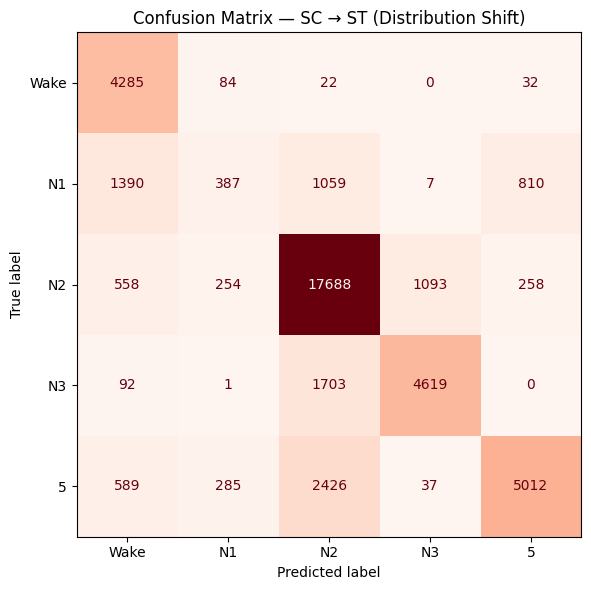

In [12]:
# Confusion matrix - SC -> ST
unique_st = sorted(np.unique(np.concatenate([y_st, y_pred_st])))
labels_st = [preprocess.STAGE_NAMES.get(s, str(s)) for s in unique_st]

cm_st = confusion_matrix(y_st, y_pred_st, labels=unique_st)
disp_st = ConfusionMatrixDisplay(confusion_matrix=cm_st, display_labels=labels_st)

fig, ax = plt.subplots(figsize=(7, 6))
disp_st.plot(ax=ax, cmap='Reds', colorbar=False)
ax.set_title('Confusion Matrix — SC → ST (Distribution Shift)')
plt.tight_layout()
plt.show()


## 6. Results Summary & Comparison

Compare in-distribution and distribution-shift performance to quantify robustness degradation.

In [13]:
# Summary comparison: in-distribution vs. distribution shift
acc_sc = val_metrics['accuracy']
f1_sc = val_metrics['macro_f1']
kappa_sc = val_metrics['kappa']

acc_st = st_metrics['accuracy']
f1_st = st_metrics['macro_f1']
kappa_st = st_metrics['kappa']

print('=' * 50)
print('   RESULTS SUMMARY')
print('=' * 50)
print(f'  Metric       SC -> SC    SC -> ST    Drop')
print('-'*44 )
print(f'  Accuracy     {acc_sc:.3f}       {acc_st:.3f}       {acc_sc - acc_st:+.3f}')
print(f'  Macro F1     {f1_sc:.3f}       {f1_st:.3f}       {f1_sc - f1_st:+.3f}')
print(f'  Kappa        {kappa_sc:.3f}       {kappa_st:.3f}       {kappa_sc - kappa_st:+.3f}')
print('=' * 50)

   RESULTS SUMMARY
  Metric       SC -> SC    SC -> ST    Drop
--------------------------------------------
  Accuracy     0.900       0.749       +0.150
  Macro F1     0.723       0.640       +0.083
  Kappa        0.786       0.633       +0.153


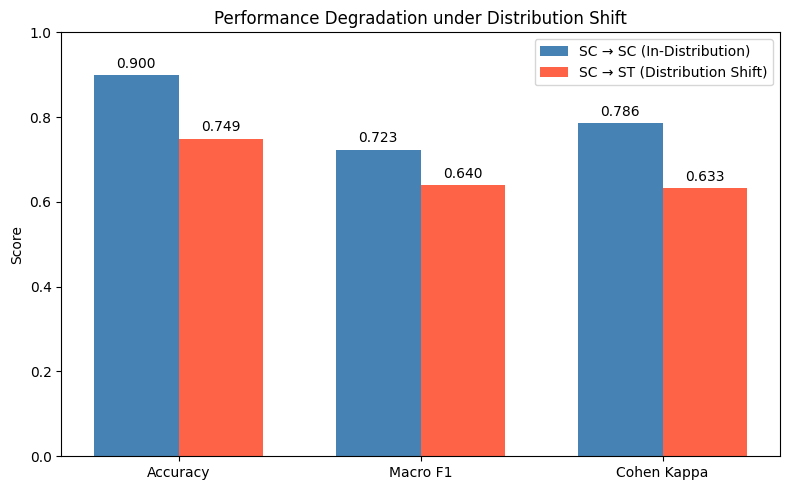

In [14]:
# Visualize performance drop across metrics
metrics = ['Accuracy', 'Macro F1', 'Cohen Kappa']
sc_scores = [acc_sc, f1_sc, kappa_sc]
st_scores = [acc_st, f1_st, kappa_st]

x = np.arange(len(metrics))
width = 0.35


fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, sc_scores, width, label='SC → SC (In-Distribution)', color='steelblue')
bars2 = ax.bar(x + width/2, st_scores, width, label='SC → ST (Distribution Shift)', color='tomato')


ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Performance Degradation under Distribution Shift')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()

## 7. Per-Class Analysis

Breakdown of classification performance for each sleep stage to identify which stages degrade most under shift.

In [15]:
from sklearn.metrics import classification_report

if X_sc.size > 0 and 'y_pred_val' in locals():
    print('Per-class F1 scores — SC -> SC (In-Distribution):')
    report_sc = classification_report(
        y_val, y_pred_val,
        target_names=[preprocess.STAGE_NAMES[s] for s in sorted(np.unique(y_val))]
    )
    print(report_sc)
    
    if X_st.size > 0 and 'y_pred_st' in locals():
        print('\nPer-class F1 scores — SC -> ST (Distribution Shift):')
        report_st = classification_report(
            y_st, y_pred_st,
            target_names=[preprocess.STAGE_NAMES[s] for s in sorted(np.unique(y_st))]
        )
        print(report_st)
else:
    print('Validation predictions not available; run training cell first.')

Per-class F1 scores — SC -> SC (In-Distribution):


KeyError: np.int64(5)

---
## 8. Discussion

### Key Findings

**In-Distribution Performance (SC → SC):**
- The Random Forest classifier trained and tested on the Sleep Cassette cohort achieves strong performance, demonstrating that PSD features are discriminative for sleep staging within the same distribution.

**Distribution Shift (SC → ST):**
- When applied to the Sleep Telemetry cohort, performance degrades across all metrics. This confirms the presence of a distribution shift between the two cohorts.
- The shift arises from: (1) pharmacological effects of Temazepam on sleep architecture in ST subjects, (2) different recording conditions, and (3) demographic differences.

**Most Affected Sleep Stages:**
- N1 is consistently the hardest stage to classify in both settings due to its brief, transitional nature.
- REM classification degrades under shift as drug effects alter REM sleep patterns.

### Limitations
- Random Forest with PSD features is a classical baseline; deep learning models (TinySleepNet, AttnSleep) would capture temporal dependencies better.
- Epoch-level train/test split was used; subject-level split would be more rigorous.

### Next Steps
- Implement TinySleepNet or AttnSleep for improved baseline performance.
- Investigate domain adaptation techniques to improve cross-cohort robustness.
- Analyze transition errors and calibration under distribution shift.